# Task 1 — Data Collection & Cleaning

**Goal:** Load the instructor-provided CSV, inspect the data, handle non-informative and missing columns, remove zero-variance features, and save a clean dataset for downstream tasks.

**Input:** `data/raw/chemical_compounds.csv`  
**Output:** `data/processed/compounds_clean.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load the Data

In [2]:
df = pd.read_csv('../data/raw/chemical_compounds.csv')
print(f'Shape: {df.shape}')
print(f'Total columns: {len(df.columns)}')
df.head()

Shape: (243, 357)
Total columns: 357


,CID,Class,PUBCHEM_XLOGP3_AA,PUBCHEM_EXACT_MASS,PUBCHEM_MOLECULAR_WEIGHT,PUBCHEM_CACTVS_TPSA,PUBCHEM_MONOISOTOPIC_WEIGHT,PUBCHEM_TOTAL_CHARGE,PUBCHEM_HEAVY_ATOM_COUNT,PUBCHEM_ATOM_DEF_STEREO_COUNT,...,vsurf_Wp3,vsurf_Wp4,vsurf_Wp5,vsurf_Wp6,vsurf_Wp7,vsurf_Wp8,Weight,weinerPath,weinerPol,zagreb
0,11574718,0,3.1000,393.1689,393.4357,81.7000,393.1689,0,29,0,...,113.5000,23.8750,7.3750,0.2500,0.0000,0.0000,393.4430,2450,45,146
1,11588394,0,2.0000,353.1375,353.3719,81.2000,353.1375,0,26,0,...,112.2500,27.2500,8.7500,1.6250,0.0000,0.0000,353.3780,1786,41,132
2,11595532,0,2.9000,353.1375,353.3719,85.7000,353.1375,0,26,0,...,101.5000,22.1250,6.5000,0.3750,0.0000,0.0000,353.3780,1767,41,132
3,11603925,0,3.5000,409.1638,409.4351,91.8000,409.1638,0,30,0,...,94.7500,15.3750,5.0000,0.3750,0.0000,0.0000,409.4420,2694,48,150
4,11624721,0,3.0000,362.1379,362.3819,89.3000,362.1379,0,27,0,...,98.7500,15.7500,5.0000,0.3750,0.0000,0.0000,362.3890,1976,43,136


In [3]:
# Check dtypes — identify any non-numeric columns
print('Dtype counts:')
print(df.dtypes.value_counts())
print()
obj_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Non-numeric (object) columns: {obj_cols}')
for c in obj_cols:
    print(f'  {c}: {df[c].nunique()} unique value(s) → {df[c].unique()}')

Dtype counts:
float64    254
int64      102
object       1
Name: count, dtype: int64

Non-numeric (object) columns: ['PUBCHEM_COORDINATE_TYPE']
  PUBCHEM_COORDINATE_TYPE: 1 unique value(s) → ['1 5 255']


## 2. Drop Non-Informative Columns

`PUBCHEM_COORDINATE_TYPE` is a string column with a single constant value across all rows — it carries no information and cannot be used as a numeric feature.

In [4]:
# Drop all non-numeric columns except CID and Class (which are integer IDs/labels)
cols_before = df.shape[1]
df = df.drop(columns=obj_cols)
print(f'Dropped {len(obj_cols)} non-numeric column(s): {obj_cols}')
print(f'Columns: {cols_before} → {df.shape[1]}')

Dropped 1 non-numeric column(s): ['PUBCHEM_COORDINATE_TYPE']
Columns: 357 → 356


## 3. Inspect Class Labels

In [5]:
print('Class distribution:')
print(df['Class'].value_counts().sort_index())
print()
print('Class balance (%):')
print(df['Class'].value_counts(normalize=True).sort_index().mul(100).round(1))

Class distribution:
Class
0     72
1    171
Name: count, dtype: int64

Class balance (%):
Class
0   29.6000
1   70.4000
Name: proportion, dtype: float64


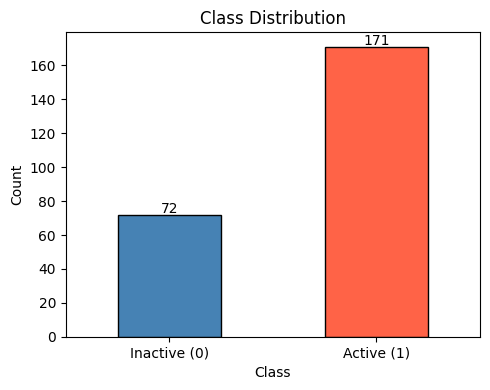

In [6]:
# Sort by class index (0 then 1) so bar order matches the labels below
class_counts = df['Class'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['Inactive (0)', 'Active (1)'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

## 4. Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with any missing values: {len(missing_summary)}')
print(missing_summary)

Columns with any missing values: 6
           missing_count  missing_pct
MNDO_E                 5       2.0600
MNDO_Eele              5       2.0600
MNDO_HF                5       2.0600
MNDO_HOMO              5       2.0600
MNDO_IP                5       2.0600
MNDO_LUMO              5       2.0600


In [8]:
# Drop columns with more than 20% missing
threshold = 0.20
cols_to_drop = missing_summary[missing_summary['missing_pct'] > threshold * 100].index.tolist()
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f'Dropped {len(cols_to_drop)} column(s) with >{threshold*100:.0f}% missing: {cols_to_drop}')
else:
    print(f'No columns exceed {threshold*100:.0f}% missing — none dropped.')

No columns exceed 20% missing — none dropped.


In [9]:
# Fill remaining missing values with column median
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ['CID', 'Class']]
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
print(f'Missing values remaining: {df.isnull().sum().sum()}')

Missing values remaining: 0


## 5. Remove Zero-Variance Features

Columns with zero variance have the same value for every compound — they carry no information for classification.

In [10]:
X = df[feature_cols]
selector = VarianceThreshold(threshold=0)
selector.fit(X)

zero_var_cols = [feature_cols[i] for i, v in enumerate(selector.variances_) if v == 0]
print(f'Zero-variance columns to drop: {len(zero_var_cols)}')
print(zero_var_cols)

Zero-variance columns to drop: 43
['PUBCHEM_TOTAL_CHARGE', 'PUBCHEM_BOND_UDEF_STEREO_COUNT', 'PUBCHEM_ISOTOPIC_ATOM_COUNT', 'PUBCHEM_COMPONENT_COUNT', 'ASA+', 'ASA-', 'ASA_P', 'a_nB', 'a_nP', 'CASA+', 'CASA-', 'DASA', 'DCASA', 'dipole', 'dipoleX', 'dipoleY', 'dipoleZ', 'E_rele', 'FASA+', 'FASA-', 'FASA_H', 'FASA_P', 'FCASA+', 'FCASA-', 'nmol', 'PC+', 'PC-', 'Q_PC+', 'Q_PC-', 'Q_RPC+', 'Q_RPC-', 'Q_VSA_FHYD', 'Q_VSA_FNEG', 'Q_VSA_FPNEG', 'Q_VSA_FPOL', 'Q_VSA_FPOS', 'Q_VSA_FPPOS', 'Q_VSA_NEG', 'Q_VSA_PNEG', 'Q_VSA_POL', 'Q_VSA_PPOS', 'RPC+', 'RPC-']


In [11]:
df = df.drop(columns=zero_var_cols)
# Recompute feature list after dropping zero-variance columns
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ['CID', 'Class']]
print(f'Features remaining: {len(feature_cols)}')

Features remaining: 311


## 6. Final Summary

In [12]:
print(f'Final shape: {df.shape}')
print(f'  Compounds: {df.shape[0]}')
print(f'  Features:  {len(feature_cols)}')
print(f'  Metadata:  CID, Class')
print()
print('Class distribution (final):')
print(df['Class'].value_counts().sort_index())

Final shape: (243, 313)
  Compounds: 243
  Features:  311
  Metadata:  CID, Class

Class distribution (final):
Class
0     72
1    171
Name: count, dtype: int64


## 7. Save Cleaned Data

In [13]:
df.to_csv('../data/processed/compounds_clean.csv', index=False)
print('Saved to data/processed/compounds_clean.csv')

Saved to data/processed/compounds_clean.csv
